## **Session 3** - Logistic Regression
این یکی از روش های ابتدایی و ساده در $Classification$ است که برای مسائل باینری استفاده می شود که فقط دو نتیجه احتمالی وجود دارد.

علاوه بر اینکه به خودی خود کاربرد های زیادی دارد، فهمیدن آن به فهمیدن سایر الگوریتم های $Classification$ کمک می کند.

رگرسیون لجستیک احتمال تعلق یک نمونه به یک کلاس خاص را پیش‌بینی می‌کند.

![](images/img_2.png)

**نکته:** بسیاری از مسائلی که از نوع رگرسیون و پیوسته هستند را می توان به مسائلی از نوع دسته بندی تبدیل کرد مانند:

![](images/img_3.png)

Unlike linear regression, which outputs continuous number values, logistic regression transforms its output using the logistic sigmoid function to return a probability value. This probability can then be mapped to two or more discrete classes.

The heart of logistic regression is the logistic function, also known as the sigmoid function. This S-shaped curve can take any real-valued number and map it into a value between 0 and 1.

The logistic function is defined as:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:

- $\sigma$ is the sigmoid function
- $z$ is the input to the function (often the linear combination of features and their coefficients)
- $e$ is the base of natural logarithms (Euler's number)

---

To understand logistic regression, it's helpful to see how it relates to and differs from linear regression:

1. **Linear Regression:** $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$
2. **Logistic Regression:** $p = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n)}}$

![](images/img_4.png)





### Logistic Regression as a Generalized Linear Model
Logistic regression is a specific case of GLM where the response variable follows a Bernoulli distribution and uses the logit link function.

in the GLM framework, logistic regression consists of three components:

1. Random Component: *Bernoulli distribution*
2. Systematic Component: *Linear predictor*
3. Link Function: *Logit function*

---

#### Random Component: *Bernoulli distribution*
In logistic regression, we assume that our response variable $Y$ follows a Bernoulli distribution:

![](images/img_5.png)

The probability mass function of this distribution is:
$$P(Y = y) = p^y(1-p)^{1-y}, \quad y \in \{0, 1\}$$

---

#### Systematic component: *Linear Predictor*
The systematic component in logistic regression is a linear combination of predictors, similar to linear regression:

$$\eta = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

---

#### Link Function: Logit Function
The link function connects the random and systematic components. For logistic regression, we use the logit function:
$$g(p) = \text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \eta$$

The logit function allows us to map probabilities (bounded between 0 and 1) to an unbounded continuous scale, which is necessary for linear modeling.

![](images/img_6.png)

---

#### Putting It All Together
Combining these components, we can express logistic regression as:
$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

Solving for $p$, we get the familiar logistic function:

$$p = \frac{e^{\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n}}{1 + e^{\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n)}}$$

---

#### Maximum Likelihood Estimation

To estimate the parameters , we use Maximum Likelihood Estimation (MLE). The likelihood function for logistic regression is:
$$L(\beta) = \prod_{i=1}^n p_i^{y_i}(1-p_i)^{1-y_i}$$

Where $p_i$ is the predicted probability for the $i$-th observation.

We typically work with the log-likelihood:
$$\ell\ell(\beta) = \sum_{i=1}^n [y_i \ln(p_i) + (1-y_i) \ln(1-p_i)]$$

Two important concepts in logistic regression are odds and log-odds:

1. **Odds:** The ratio of the probability of success to the probability of failure.
$$\text{odds} = \frac{p}{1-p}$$

2. **Log-odds:** The logistic regression model assumes a linear relationship between the independent variables and the log odds of the outcome. Log-odds is then the natural logarithm of the odds, which is exactly what the logit function computes. $$\text{log-odds} = \ln\left(\frac{p}{1-p}\right)$$



### Interpreting Logistic Regression Results

---

#### What we are predicting?
Logistic regression predicts the probability of an event happening

- Output is always between 0 and 1
- Closer to 1 = More likely to happen
- Closer to 0 = Less likely to happen

Coefficients tell us how each feature (input variable) affects the probability of our event.

- **Positive coefficient:** As the feature increases, the event becomes more likely
- **Negative coefficient:** As the feature increases, the event becomes less likely
- **Larger absolute value:** The feature has a stronger effect

---

#### Odds and Odds Ratios

Odds are another way to express probability, often easier to interpret.

**Odds = Probability / (1 - Probability)**

Odds ratios show how odds change when a feature increases by one unit.

- **Odds Ratio > 1:** Feature increases the odds of the event
- **Odds Ratio < 1:** Feature decreases the odds of the event

odds = شانس

Example: An odds ratio of 1.5 means the odds increase by 50% for each unit increase in the feature.

مثال: نسبت شانس ۱.۵ به این معنی است که به ازای هر واحد افزایش در ویژگی، شانس ۵۰٪ افزایش می‌یابد.

---

#### Predicted Probabilities



In [1]:
import math

def predict_probability(age, income):
    # predict probability for a 30-year-old with an income of 50,000 to buy the product
    z = -3 + 0.05 * age + 0.001 * income  # -3 is an example intercept
    return 1 / (1 + math.exp(-z)), z

In [2]:
predict_probability(10, 500)

(0.11920292202211755, -2.0)

In [3]:
predict_probability(30, 500)

(0.2689414213699951, -1.0)

In [4]:
predict_probability(30, 2500)

(0.7310585786300049, 1.0)

### Model fitting and Optimization

---

#### The Optimization Problem

Fitting a logistic regression model involves finding the parameters (coefficients) that maximize the likelihood of observing the data given the model.

Unlike linear regression, which uses the method of least squares, logistic regression typically uses Maximum Likelihood Estimation (MLE). Our goal is to maximize the log-likelihood function:$$\ell(\beta) = \sum_{i=1}^n [y_i \log(p_i) + (1-y_i) \log(1-p_i)]$$

---

#### Gradient Descent for Logistic Regression

We can use gradient descent to find the optimal parameters. The main difference from linear regression is in the computation of the gradient.

در نهایت پس از مراحل بسیار به این نتیجه میرسیم:

$$\nabla \ell(\beta) = X^T(y - p)$$

Where:

- $X$ is the design matrix (each row is an observation, each column a feature)
- $y$ is the vector of observed outcomes
- $p$ is the vector of predicted probabilities

**[Details of steps in this link](https://github.com/pytopia/Machine-Learning/blob/main/Lectures/07%20Supervised%20Learning%20-%20Classification/03%20Logistic%20Regression%20as%20a%20GLM.ipynb)**


![](images/logistic-learning.gif)

### Implementing Logistic Regression with Gradient Descent


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

In [3]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [6]:
# Gradient computation
def compute_gradient_logistic(X, y, beta):
    n = X.shape[0]
    p = sigmoid(X @ beta)
    return X.T @ (p - y) / n

In [7]:
# Cost computation
def compute_cost_logistic(X, y, beta):
    n = X.shape[0]
    p = sigmoid(X @ beta)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)) / n

In [8]:
# Mini-batch gradient descent
def mini_batch_gradient_descent_logistic(X, y, learning_rate=0.1, num_epoch=1000, batch_size=32):
    n, m = X.shape
    beta = np.zeros((m, 1))
    cost_history = []

    for _ in range(num_epoch):
        shuffled_indices = np.random.permutation(n)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, n, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            gradient = compute_gradient_logistic(xi, yi, beta)
            beta -= learning_rate * gradient

        cost = compute_cost_logistic(X, y, beta)
        cost_history.append(cost)

    return beta, cost_history

In [9]:
import numpy as np

np.random.seed(0)

# Generate random data
n_samples = 1000
n_features = 2

X = np.random.randn(n_samples, n_features)

# Create a decision boundary with some noise
boundary = X[:, 0] + X[:, 1] + np.random.normal(0, 0.5, n_samples)

# Assign labels based on the noisy boundary
y = (boundary > 0).astype(int).reshape(-1, 1)

# Print class distribution
print("Class distribution:")
print(np.bincount(y.flatten()))

Class distribution:
[516 484]


In [12]:
X

array([[ 1.76405235,  0.40015721],
       [ 0.97873798,  2.2408932 ],
       [ 1.86755799, -0.97727788],
       ...,
       [ 0.19782817,  0.0977508 ],
       [ 1.40152342,  0.15843385],
       [-1.14190142, -1.31097037]], shape=(1000, 2))

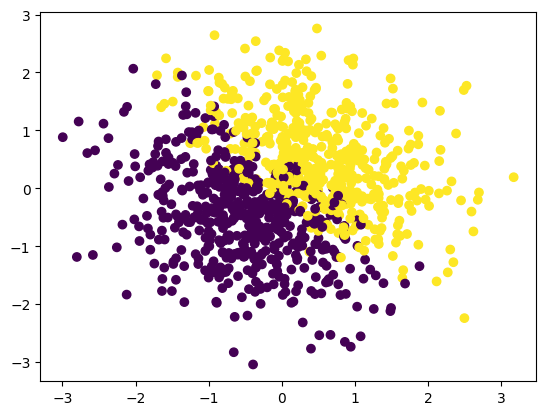

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')

- در این مرحله تسک ما درواقع پیدا کردن خطی است که به بهترین نحو بتواند نقطه های زرد را از بنفش جدا کند
- هرچند جدا کردن تمام آنها با دقت 100 درصد امکان پذیر نیست، ما همواره در تلاش برای رسیدن به بهترین درصد عملکرد هستیم.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape

(800, 2)

In [16]:
X_test.shape

(200, 2)

In [17]:
# Add intercept term
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

In [18]:
# Fit the model
beta, cost_history = mini_batch_gradient_descent_logistic(X_train, y_train)

In [19]:
beta

array([[-0.30531003],
       [ 4.48633809],
       [ 4.351934  ]])

SO:

| $\beta_0$ | -0.305310 |
|-----------|-----------|
| $\beta_1$ | 4.486338  |
| $beta_2$  | 4.351934  |

In [21]:
cost_history

[np.float64(0.4825406845638025),
 np.float64(0.3962879686296232),
 np.float64(0.35033981980045215),
 np.float64(0.32149891722130697),
 np.float64(0.3016099587774974),
 np.float64(0.2869671477093491),
 np.float64(0.27571080921634705),
 np.float64(0.2667690739164101),
 np.float64(0.2594784268418346),
 np.float64(0.2534319054788428),
 np.float64(0.2483357536294393),
 np.float64(0.24396051837818022),
 np.float64(0.24015950879988707),
 np.float64(0.2368461575592395),
 np.float64(0.2339257885887637),
 np.float64(0.23132905930094305),
 np.float64(0.22900700535843807),
 np.float64(0.22692390789697947),
 np.float64(0.22503761075810347),
 np.float64(0.22332974469411862),
 np.float64(0.22177200684971957),
 np.float64(0.22035016010009506),
 np.float64(0.2190441928459202),
 np.float64(0.21784201601180533),
 np.float64(0.21673338084069024),
 np.float64(0.21570855817214457),
 np.float64(0.2147585330743508),
 np.float64(0.21387781999548922),
 np.float64(0.21305631701205902),
 np.float64(0.212289987389

In [26]:
sigmoid(X_test[0] @ beta)

array([0.99930807])

In [27]:
sigmoid(X_test[1] @ beta)

array([0.13628379])

In [28]:
sigmoid(X_test[2] @ beta)

array([0.21767235])

In [29]:
y_pred = sigmoid(X_test @ beta)

In [30]:
y_pred

array([[9.99308066e-01],
       [1.36283788e-01],
       [2.17672351e-01],
       [7.70128917e-03],
       [1.31027542e-03],
       [1.96327483e-02],
       [9.99079800e-01],
       [6.02403064e-05],
       [9.69147046e-01],
       [9.99961593e-01],
       [9.45688185e-01],
       [7.14553461e-04],
       [9.66626641e-01],
       [9.99909242e-01],
       [7.47387170e-02],
       [2.26176499e-01],
       [9.99801355e-01],
       [9.98871829e-01],
       [9.98865056e-01],
       [9.99907973e-01],
       [9.84375240e-01],
       [9.78369988e-01],
       [9.99079244e-01],
       [9.99999605e-01],
       [9.98338824e-01],
       [8.29986630e-06],
       [9.99435948e-01],
       [7.65247744e-01],
       [6.66331577e-03],
       [3.22899066e-01],
       [3.80469954e-07],
       [3.93861202e-01],
       [9.69959621e-01],
       [8.99861394e-04],
       [2.61768028e-05],
       [9.99798522e-01],
       [6.84400419e-01],
       [8.11928880e-01],
       [9.99996201e-01],
       [9.98442384e-01],


In [34]:
y_pred > 0.8 # threshold

array([[ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [

In [36]:
accuracy_score(y_test, y_pred > 0.5)

0.9

In [38]:
accuracy_score(y_test, y_pred > 0.99)

0.755

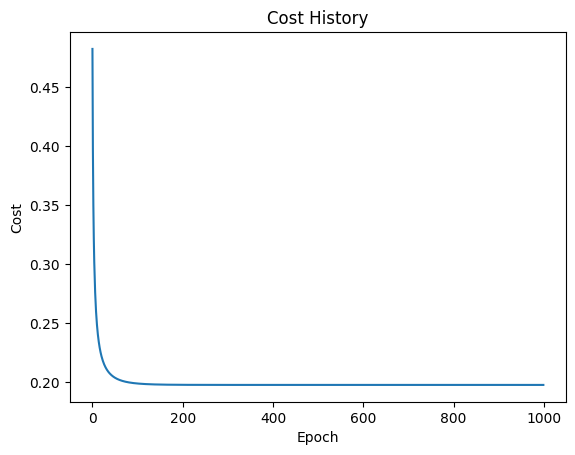

In [39]:
plt.plot(cost_history)
plt.title("Cost History")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

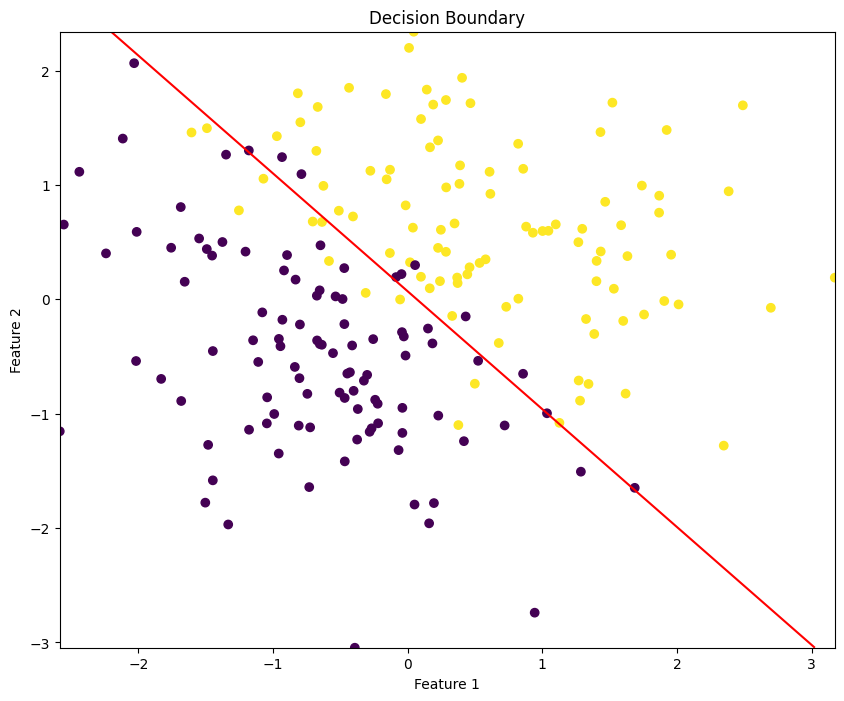

In [40]:
# Plot decision boundary
plt.figure(figsize=(10, 8))
plt.scatter(X_test[:, 1], X_test[:, 2], c=y_test, cmap='viridis')
x1_min, x1_max = X_test[:, 1].min(), X_test[:, 1].max()
x2_min, x2_max = X_test[:, 2].min(), X_test[:, 2].max()
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))
Z = sigmoid(np.c_[np.ones((xx1.ravel().shape[0], 1)), xx1.ravel(), xx2.ravel()] @ beta)
Z = Z.reshape(xx1.shape)
plt.contour(xx1, xx2, Z, [0.5], colors='r')
plt.title('Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

#### Interpreting the Results
After running this code, we'll get:

1. The model's accuracy and log loss on the test set.
2. A plot of the cost history, showing how the cost decreases over epochs.
3. A visualization of the decision boundary on the test data.
A good fit is indicated by:

- High accuracy (close to 1) and low log loss on the test set
- A smoothly decreasing cost history that plateaus
- A decision boundary that clearly separates the two classes